# PyRadtran xarray Accessor Showcase

This notebook demonstrates how to use the PyRadtran xarray accessor to simplify radiative transfer calculations. The xarray accessor provides a clean interface to run PyRadtran simulations directly from xarray datasets, making it easier to integrate with data analysis workflows.

## Setup and Configuration

First, we'll import the necessary libraries and set up our environment. This includes:

1. Standard data science libraries (numpy, pandas, xarray)
2. PyRadtran modules
3. Plotting libraries for visualization

In [ ]:
import os
import sys
import logging
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import yaml
from dataclasses import asdict

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')
logger = logging.getLogger('pyradtran')

# Add parent directory to path if needed (assuming notebook is in notebooks/ directory)
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Import PyRadtran modules
from pyradtran.config import PathsConfig, SimulationDefaults, SimulationConfig, ExecutionConfig, OutputConfig, load_config
from pyradtran.core import Simulation, generate_input_content
from pyradtran.io import parse_uvspec_output
from pyradtran.interface import PyRadtranAccessor  # This should register the accessor automatically

print("Setup complete!")

Added /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran to sys.path
Setup complete!


## Define Paths and Constants

Now we'll define the necessary paths for LibRadtran data and executables, as well as working directories.

In [ ]:
# Define paths
LIBRADTRAN_DATA_PATH = '/opt/libradtran/2.0.4/share/libRadtran/data'
LIBRADTRAN_EXEC_PATH = '/opt/libradtran/2.0.4/bin/uvspec'
ATMOSPHERE_FILE = '/projekt_agmwend/data/HALO-AC3/05_VELOX_Tools/add_data/afglsw.dat'
SOLAR_SPECTRUM_FILE = '/projekt_agmwend/home_rad/sophie/libradtran/solar_flux/NewGuey2003.dat'
WORKING_DIR = os.path.join(module_path, 'work')

# Create working directory if it doesn't exist
os.makedirs(WORKING_DIR, exist_ok=True)

print(f"Working directory: {WORKING_DIR}")

Working directory: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work


## Create PyRadtran Configuration

Let's create a configuration object for our simulation based on the debug_simple_case.py example.

In [ ]:
def create_pyradtran_config(wavelength_range=[400, 700], integrate_wavelength=True):
    """Create a configuration for PyRadtran simulation."""
    config = SimulationConfig(
        paths=PathsConfig(
            libradtran_bin=Path(LIBRADTRAN_EXEC_PATH),
            libradtran_data=Path(LIBRADTRAN_DATA_PATH),
            atmosphere_profile=Path(ATMOSPHERE_FILE),
            solar_spectrum=Path(SOLAR_SPECTRUM_FILE),
            output_dir=Path(WORKING_DIR),
            working_dir=Path(WORKING_DIR)
        ),
        simulation_defaults=SimulationDefaults(
            rte_solver='disort',
            mol_abs_param='lowtran per_nm',
            wavelength_nm=wavelength_range,
            output_columns=['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo'],
            output_altitudes_km=[0.0, 1.0, 2.0, 3.0],  # Multiple altitudes for testing
            albedo_type='const',
            albedo_value=0.3,
            aerosols={'enabled': False},
            clouds={'enabled': False},
            integrate_wavelength=integrate_wavelength
        ),
        execution=ExecutionConfig(
            max_workers=1,
            cleanup_temp_files=False,
            debug_mode=True,
            timeout_seconds=60
        ),
        output=OutputConfig(
            filename_prefix="xarray_example",
            filename_suffix=".nc",
            netcdf_encoding=None
        )
    )
    
    # Add additional options
    if not hasattr(config.simulation_defaults, 'additional_options'):
        config.simulation_defaults.additional_options = []
    
    # First add per_nm normalization
    config.simulation_defaults.additional_options.append("output_process per_nm")
    
    # Then add integrate command if wavelength integration is enabled
    if config.simulation_defaults.integrate_wavelength:
        config.simulation_defaults.additional_options.append("output_process integrate")
    
    return config

# Create our config
config = create_pyradtran_config()
print(f"Configuration created with {len(config.simulation_defaults.output_altitudes_km)} altitude levels")
print(f"Output columns: {config.simulation_defaults.output_columns}")
print(f"Additional options: {config.simulation_defaults.additional_options}")

# Save the configuration to a YAML file

# Function to convert Path objects to strings in a nested dictionary
def convert_paths_to_strings(d):
    if isinstance(d, dict):
        return {k: convert_paths_to_strings(v) for k, v in d.items()}
    elif isinstance(d, list):
        return [convert_paths_to_strings(v) for v in d]
    elif isinstance(d, Path):
        return str(d)
    else:
        return d

# Convert config to dictionary and handle Path objects
config_dict = {
    'paths': asdict(config.paths),
    'simulation_defaults': asdict(config.simulation_defaults),
    'execution': asdict(config.execution),
    'output': asdict(config.output)
}

# Convert Path objects to strings
config_dict = convert_paths_to_strings(config_dict)

# Save configuration to YAML file
config_file_path = os.path.join(WORKING_DIR, 'showcase_config.yaml')
with open(config_file_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False)

print(f"Configuration saved to {config_file_path}")

Configuration created with 4 altitude levels
Output columns: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Additional options: ['output_process per_nm', 'output_process integrate']
Configuration saved to /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/showcase_config.yaml


## Create a Sample xarray Dataset

Now we'll create a sample xarray dataset with time, latitude, and longitude coordinates. This will be the input for our PyRadtran simulations.

In [ ]:
def create_sample_dataset():
    """Create a sample dataset with time, latitude, and longitude coordinates."""
    # Create a time series for a single day
    times = pd.date_range(start="2022-04-01", periods=24, freq="1H")
    
    # Create latitude and longitude arrays
    # Let's simulate a flight path over the Arctic
    latitudes = np.linspace(72.0, 78.0, 24)  # From 72°N to 78°N
    longitudes = np.linspace(-10.0, 10.0, 24)  # From 10°W to 10°E
    
    # Create the dataset
    ds = xr.Dataset(
        coords={
            'time': times
        },
        data_vars={
            'latitude': ('time', latitudes),
            'longitude': ('time', longitudes)
        },
        attrs={
            'description': 'Sample dataset for PyRadtran xarray accessor showcase',
            'created': datetime.now().isoformat()
        }
    )
    
    return ds

# Create the sample dataset
sample_ds = create_sample_dataset()

# Display the dataset
print("Sample Dataset Info:")
print(f"Dimensions: {dict(sample_ds.dims)}")
print(f"Variables: {list(sample_ds.data_vars)}")
print("\nPreview of the dataset:")
display(sample_ds.head())

Sample Dataset Info:
Dimensions: {'time': 24}
Variables: ['latitude', 'longitude']

Preview of the dataset:


/tmp/ipykernel_1731777/429806114.py:4: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  times = pd.date_range(start="2022-04-01", periods=24, freq="1H")
/tmp/ipykernel_1731777/429806114.py:33: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(sample_ds.dims)}")


<xarray.Dataset> Size: 120B
Dimensions:    (time: 5)
Coordinates:
  * time       (time) datetime64[ns] 40B 2022-04-01 ... 2022-04-01T04:00:00
Data variables:
    latitude   (time) float64 40B 72.0 72.26 72.52 72.78 73.04
    longitude  (time) float64 40B -10.0 -9.13 -8.261 -7.391 -6.522
Attributes:
    description:  Sample dataset for PyRadtran xarray accessor showcase
    created:      2025-05-06T16:23:32.975794

## Running PyRadtran for a Single Point

Let's first test the xarray accessor by running a simulation for a single point (time, latitude, longitude).

In [ ]:
# Create a single-point dataset
single_point_ds = xr.Dataset(
    coords={
        'time': [pd.Timestamp("2022-04-01T12:00:00")],
        'latitude': [75.0],
        'longitude': [0.0],
        'altitude': [1.0, 2.0, 3.0]  # Adding altitude for the simulation
    },
)

print("Single point dataset created:")
display(single_point_ds)

# Run the simulation using the xarray accessor
result_ds = single_point_ds.pyradtran.run_uvspec(
    config_path=os.path.join(WORKING_DIR, 'showcase_config.yaml'),  # Use the saved config file path
    return_dataset=True,
    save_to_file=True
)

print("\nSimulation result:")
display(result_ds)

Single point dataset created:


<xarray.Dataset> Size: 48B
Dimensions:    (time: 1, latitude: 1, longitude: 1, altitude: 3)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-04-01T12:00:00
  * latitude   (latitude) float64 8B 75.0
  * longitude  (longitude) float64 8B 0.0
  * altitude   (altitude) float64 24B 1.0 2.0 3.0
Data variables:
    *empty*

2025-05-06 16:23:33,118 - pyradtran.config - INFO - Loading configuration from: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/showcase_config.yaml
2025-05-06 16:23:33,125 - pyradtran.config - INFO - Configuration loaded successfully.
2025-05-06 16:23:33,126 - pyradtran.interface - INFO - Overriding configuration altitude with 3 levels from dataset: [1. 2. 3.]
2025-05-06 16:23:33,127 - pyradtran.interface - INFO - Running 1 simulations across time/location points...
2025-05-06 16:23:34,718 - pyradtran.io - INFO - Parsing as multi-altitude data with 3 levels
2025-05-06 16:23:34,740 - pyradtran.interface - INFO - Completed 1/1 simulations with 7 output variables
2025-05-06 16:23:34,742 - pyradtran.io - INFO - Saving results to NetCDF file: /projekt_agmwend/home_rad/Joshua/HALO-AC3_Arctic_leads/sim/pyradtran/work/xarray_example_20250506_162334.nc
2025-05-06 16:23:34,747 - pyradtran.io - ERROR - Error adding sza to dataset: float() argument must be a string or a 


Simulation result:


<xarray.Dataset> Size: 216B
Dimensions:    (time: 1, latitude: 1, longitude: 1, altitude: 3)
Coordinates:
  * time       (time) datetime64[ns] 8B 2022-04-01T12:00:00
  * latitude   (latitude) float64 8B 75.0
  * longitude  (longitude) float64 8B 0.0
  * altitude   (altitude) float64 24B 1.0 2.0 3.0
Data variables:
    sza        (time, altitude) float64 24B 70.36 70.36 70.36
    edir       (time, altitude) float64 24B 1.227e+05 1.278e+05 1.326e+05
    eglo       (time, altitude) float64 24B 1.505e+05 1.532e+05 1.557e+05
    edn        (time, altitude) float64 24B 2.78e+04 2.547e+04 2.318e+04
    eup        (time, altitude) float64 24B 4.686e+04 4.923e+04 5.133e+04
    enet       (time, altitude) float64 24B 1.036e+05 1.04e+05 1.044e+05
    albedo     (time, altitude) float64 24B 0.3115 0.3212 0.3296
Attributes:
    generated_by:     pyradtran
    altitude_levels:  3 levels (km): 1.0, 2.0, 3.0

## Exploring the Results

Now let's explore the results of our simulation. We'll look at the structure of the output dataset and plot some of the key variables.

In [ ]:
# Examine the structure of the result dataset
print("Result Dataset Structure:")
print(f"Dimensions: {dict(result_ds.dims)}")
print(f"Coordinates: {list(result_ds.coords)}")
print(f"Data variables: {list(result_ds.data_vars)}")
print(f"Attributes: {result_ds.attrs}")

# Check if we have altitude dimension
has_altitude = 'altitude' in result_ds.dims
print(f"\nHas altitude dimension: {has_altitude}")
if has_altitude:
    print(f"Altitude levels: {result_ds.altitude.values} km")

Result Dataset Structure:
Dimensions: {'time': 1, 'latitude': 1, 'longitude': 1, 'altitude': 3}
Coordinates: ['time', 'latitude', 'longitude', 'altitude']
Data variables: ['sza', 'edir', 'eglo', 'edn', 'eup', 'enet', 'albedo']
Attributes: {'generated_by': 'pyradtran', 'altitude_levels': '3 levels (km): 1.0, 2.0, 3.0'}

Has altitude dimension: True
Altitude levels: [1. 2. 3.] km


/tmp/ipykernel_1731777/4100706038.py:3: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  print(f"Dimensions: {dict(result_ds.dims)}")


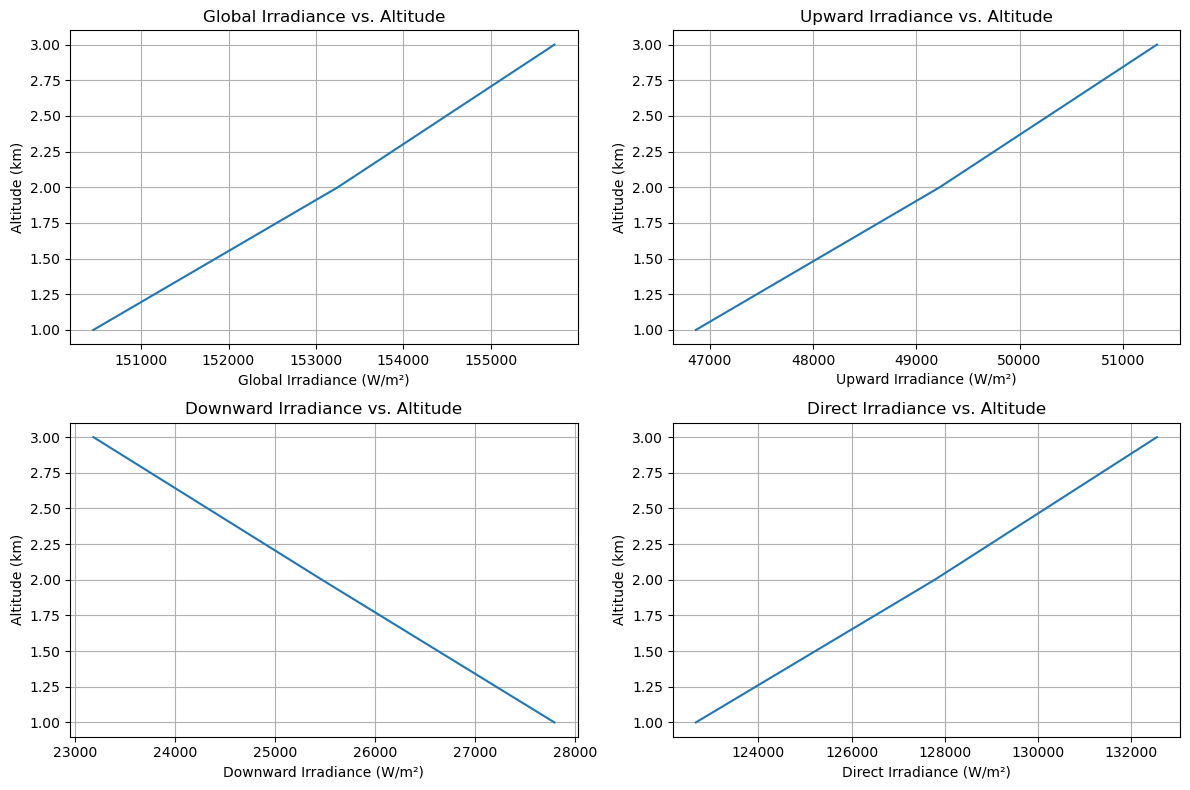

In [ ]:
# Plot some of the key variables
plt.figure(figsize=(12, 8))

if has_altitude:
    # If we have altitude dimension, plot eglo vs altitude
    plt.subplot(2, 2, 1)
    result_ds.eglo.plot(y='altitude')
    plt.title('Global Irradiance vs. Altitude')
    plt.xlabel('Global Irradiance (W/m²)')
    plt.ylabel('Altitude (km)')
    plt.grid(True)
    
    # Plot eup vs altitude
    plt.subplot(2, 2, 2)
    result_ds.eup.plot(y='altitude')
    plt.title('Upward Irradiance vs. Altitude')
    plt.xlabel('Upward Irradiance (W/m²)')
    plt.ylabel('Altitude (km)')
    plt.grid(True)
    
    # Plot edn vs altitude
    plt.subplot(2, 2, 3)
    result_ds.edn.plot(y='altitude')
    plt.title('Downward Irradiance vs. Altitude')
    plt.xlabel('Downward Irradiance (W/m²)')
    plt.ylabel('Altitude (km)')
    plt.grid(True)
    
    # Plot edir vs altitude
    plt.subplot(2, 2, 4)
    result_ds.edir.plot(y='altitude')
    plt.title('Direct Irradiance vs. Altitude')
    plt.xlabel('Direct Irradiance (W/m²)')
    plt.ylabel('Altitude (km)')
    plt.grid(True)
else:
    # If we only have time dimension, create a bar chart of irradiance components
    irradiance_vars = ['edir', 'eglo', 'edn', 'eup', 'enet']
    values = [float(result_ds[var].values) for var in irradiance_vars if var in result_ds]
    plt.bar(irradiance_vars, values)
    plt.title('Irradiance Components')
    plt.ylabel('Irradiance (W/m²)')
    plt.grid(True, axis='y')

plt.tight_layout()
plt.show()

## Running PyRadtran for Multiple Points

Now let's run a simulation for multiple points in our sample dataset. We'll use the first 6 points to keep the computation time reasonable.

In [ ]:
multi_point_ds

<xarray.Dataset> Size: 144B
Dimensions:    (time: 6)
Coordinates:
  * time       (time) datetime64[ns] 48B 2022-04-01 ... 2022-04-01T05:00:00
Data variables:
    latitude   (time) float64 48B 72.0 72.26 72.52 72.78 73.04 73.3
    longitude  (time) float64 48B -10.0 -9.13 -8.261 -7.391 -6.522 -5.652
Attributes:
    description:  Sample dataset for PyRadtran xarray accessor showcase
    created:      2025-05-06T16:23:32.975794

In [1]:
# Use the first 6 points from our sample dataset
multi_point_ds = create_sample_dataset().isel(time=slice(0, 6))
multi_point_ds = multi_point_ds.assign_coords(
    altitude=(('altitude'), [1.0, 2.0, 3.0, 4, 5, 6])  # Adding altitude for the simulation
)

print("Multi-point dataset (first 6 points):")
display(multi_point_ds)

# Run the simulation for multiple points
print("\nRunning simulation for multiple points (this may take a while)...")
multi_result_ds = multi_point_ds.pyradtran.run_uvspec(
    config_path=os.path.join(WORKING_DIR, 'showcase_config.yaml'),  # Use the saved config file path
    return_dataset=True,
    save_to_file=True
)


print("\nMulti-point simulation result:")
display(multi_result_ds)

NameError: name 'create_sample_dataset' is not defined

In [ ]:
multi_result_ds

<xarray.Dataset> Size: 2kB
Dimensions:    (time: 6, altitude: 6)
Coordinates:
  * time       (time) datetime64[ns] 48B 2022-04-01 ... 2022-04-01T05:00:00
  * altitude   (altitude) float64 48B 1.0 2.0 3.0 4.0 5.0 6.0
Data variables:
    latitude   (time) float64 48B 72.0 72.26 72.52 72.78 73.04 73.3
    longitude  (time) float64 48B -10.0 -9.13 -8.261 -7.391 -6.522 -5.652
    sza        (time, altitude) float64 288B 180.0 180.0 180.0 ... 180.0 180.0
    edir       (time, altitude) float64 288B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eglo       (time, altitude) float64 288B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    edn        (time, altitude) float64 288B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    eup        (time, altitude) float64 288B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    enet       (time, altitude) float64 288B 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    albedo     (time, altitude) float64 288B nan nan nan nan ... nan nan nan nan
Attributes:
    generated_by:     pyradtran
    altitude_levels:  6 levels (km): 1.0, 2.0, 3.0, 4.0, 5.0, 6.0

## Exploring Multi-Point Results

Let's explore and visualize the results of our multi-point simulation.

In [ ]:
# Examine structure of multi-point results
print("Multi-point Result Structure:")
print(f"Dimensions: {dict(multi_result_ds.dims)}")
print(f"Coordinates: {list(multi_result_ds.coords)}")
print(f"Data variables: {list(multi_result_ds.data_vars)}")

# Check for altitude dimension
has_altitude_multi = 'altitude' in multi_result_ds.dims
print(f"\nHas altitude dimension: {has_altitude_multi}")
if has_altitude_multi:
    print(f"Altitude levels: {multi_result_ds.altitude.values} km")

In [ ]:
# Plot multi-point results
plt.figure(figsize=(14, 10))

# Plot global irradiance vs. time for all altitudes
if has_altitude_multi:
    plt.subplot(2, 2, 1)
    for alt in multi_result_ds.altitude.values:
        multi_result_ds.sel(altitude=alt).eglo.plot(label=f"{alt} km")
    plt.title('Global Irradiance vs. Time at Different Altitudes')
    plt.xlabel('Time')
    plt.ylabel('Global Irradiance (W/m²)')
    plt.legend()
    plt.grid(True)
    
    # Plot SZA vs. time
    plt.subplot(2, 2, 2)
    multi_result_ds.sza.plot()
    plt.title('Solar Zenith Angle vs. Time')
    plt.xlabel('Time')
    plt.ylabel('SZA (degrees)')
    plt.grid(True)
    
    # Plot irradiance profile for the first time point
    first_time = multi_result_ds.time.values[0]
    plt.subplot(2, 2, 3)
    time_slice = multi_result_ds.sel(time=first_time)
    time_slice.eglo.plot(y='altitude', label='Global')
    time_slice.edir.plot(y='altitude', label='Direct')
    time_slice.eup.plot(y='altitude', label='Upward')
    plt.title(f'Irradiance Profile at {pd.Timestamp(first_time)}')
    plt.xlabel('Irradiance (W/m²)')
    plt.ylabel('Altitude (km)')
    plt.legend()
    plt.grid(True)
    
    # Plot global irradiance vs. latitude (colored by time)
    plt.subplot(2, 2, 4)
    surface_data = multi_result_ds.sel(altitude=0.0)
    sc = plt.scatter(surface_data.latitude, surface_data.eglo, 
                     c=range(len(surface_data.time)), cmap='viridis')
    plt.colorbar(sc, label='Time index')
    plt.title('Global Irradiance vs. Latitude at Surface')
    plt.xlabel('Latitude (°N)')
    plt.ylabel('Global Irradiance (W/m²)')
    plt.grid(True)
else:
    # If no altitude dimension, plot time series of different irradiance components
    plt.subplot(2, 1, 1)
    if 'eglo' in multi_result_ds:
        multi_result_ds.eglo.plot(label='Global')
    if 'edir' in multi_result_ds:
        multi_result_ds.edir.plot(label='Direct')
    if 'edn' in multi_result_ds:
        multi_result_ds.edn.plot(label='Downward')
    if 'eup' in multi_result_ds:
        multi_result_ds.eup.plot(label='Upward')
    plt.title('Irradiance Components vs. Time')
    plt.xlabel('Time')
    plt.ylabel('Irradiance (W/m²)')
    plt.legend()
    plt.grid(True)
    
    # Plot SZA vs. time
    plt.subplot(2, 1, 2)
    multi_result_ds.sza.plot()
    plt.title('Solar Zenith Angle vs. Time')
    plt.xlabel('Time')
    plt.ylabel('SZA (degrees)')
    plt.grid(True)

plt.tight_layout()
plt.show()

## Running a Spectral Simulation

Now, let's run a simulation with spectral output (without wavelength integration) to see how the results differ.

In [ ]:
# Create a configuration for spectral output
spectral_config = create_pyradtran_config(wavelength_range=[400, 700], integrate_wavelength=False)
print(f"Spectral config additional options: {spectral_config.simulation_defaults.additional_options}")

# Save spectral configuration to YAML file
spectral_config_dict = {
    'paths': asdict(spectral_config.paths),
    'simulation_defaults': asdict(spectral_config.simulation_defaults),
    'execution': asdict(spectral_config.execution),
    'output': asdict(spectral_config.output)
}

# Convert Path objects to strings
spectral_config_dict = convert_paths_to_strings(spectral_config_dict)

# Save configuration to YAML file
spectral_config_file_path = os.path.join(WORKING_DIR, 'showcase_spectral_config.yaml')
with open(spectral_config_file_path, 'w') as f:
    yaml.dump(spectral_config_dict, f, default_flow_style=False)

print(f"Spectral configuration saved to {spectral_config_file_path}")

# Run a single-point spectral simulation
spectral_result_ds = single_point_ds.pyradtran.run_uvspec(
    config_path=spectral_config_file_path,
    return_dataset=True,
    save_to_file=True
)

print("\nSpectral simulation result:")
display(spectral_result_ds)

In [ ]:
# Examine structure of spectral results
print("Spectral Result Structure:")
print(f"Dimensions: {dict(spectral_result_ds.dims)}")
print(f"Coordinates: {list(spectral_result_ds.coords)}")
print(f"Data variables: {list(spectral_result_ds.data_vars)}")

# Check for wavelength dimension
has_wavelength = 'wavelength' in spectral_result_ds.dims
print(f"\nHas wavelength dimension: {has_wavelength}")
if has_wavelength:
    print(f"Wavelength range: {spectral_result_ds.wavelength.min().values} - {spectral_result_ds.wavelength.max().values} nm")
    print(f"Number of wavelength points: {spectral_result_ds.wavelength.size}")

In [ ]:
# Plot spectral results if we have wavelength dimension
if has_wavelength:
    plt.figure(figsize=(12, 8))
    
    # Plot global irradiance vs. wavelength for the first time point
    plt.subplot(2, 2, 1)
    first_time = spectral_result_ds.time.values[0]
    if 'altitude' in spectral_result_ds.dims:
        # If we have altitude dimension, plot for each altitude
        for alt in spectral_result_ds.altitude.values:
            spectral_result_ds.sel(time=first_time, altitude=alt).eglo.plot(
                x='wavelength', label=f"{alt} km")
    else:
        # Otherwise just plot the first time point
        spectral_result_ds.sel(time=first_time).eglo.plot(x='wavelength')
    plt.title('Global Irradiance vs. Wavelength')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Global Irradiance (W/m²/nm)')
    plt.grid(True)
    if 'altitude' in spectral_result_ds.dims:
        plt.legend()
    
    # Plot direct irradiance vs. wavelength
    plt.subplot(2, 2, 2)
    if 'altitude' in spectral_result_ds.dims:
        for alt in spectral_result_ds.altitude.values:
            spectral_result_ds.sel(time=first_time, altitude=alt).edir.plot(
                x='wavelength', label=f"{alt} km")
    else:
        spectral_result_ds.sel(time=first_time).edir.plot(x='wavelength')
    plt.title('Direct Irradiance vs. Wavelength')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Direct Irradiance (W/m²/nm)')
    plt.grid(True)
    if 'altitude' in spectral_result_ds.dims:
        plt.legend()
    
    # Plot upward irradiance vs. wavelength
    plt.subplot(2, 2, 3)
    if 'altitude' in spectral_result_ds.dims:
        for alt in spectral_result_ds.altitude.values:
            spectral_result_ds.sel(time=first_time, altitude=alt).eup.plot(
                x='wavelength', label=f"{alt} km")
    else:
        spectral_result_ds.sel(time=first_time).eup.plot(x='wavelength')
    plt.title('Upward Irradiance vs. Wavelength')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Upward Irradiance (W/m²/nm)')
    plt.grid(True)
    if 'altitude' in spectral_result_ds.dims:
        plt.legend()
    
    # Plot downward irradiance vs. wavelength
    plt.subplot(2, 2, 4)
    if 'altitude' in spectral_result_ds.dims:
        for alt in spectral_result_ds.altitude.values:
            spectral_result_ds.sel(time=first_time, altitude=alt).edn.plot(
                x='wavelength', label=f"{alt} km")
    else:
        spectral_result_ds.sel(time=first_time).edn.plot(x='wavelength')
    plt.title('Downward Irradiance vs. Wavelength')
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Downward Irradiance (W/m²/nm)')
    plt.grid(True)
    if 'altitude' in spectral_result_ds.dims:
        plt.legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("No wavelength dimension found in the results. Cannot create spectral plots.")

## Conclusion

In this notebook, we've demonstrated how to use the PyRadtran xarray accessor to perform radiative transfer simulations directly from xarray datasets. This approach offers several advantages:

1. **Seamless Integration**: The accessor integrates PyRadtran with the xarray ecosystem, allowing for easy data manipulation and analysis.
2. **Multi-dimensional Analysis**: We can easily handle simulations with multiple dimensions (time, altitude, wavelength).
3. **Rich Visualization**: Results can be visualized with xarray's built-in plotting functions integrated with matplotlib.
4. **Flexible Configuration**: The PyRadtran configuration can be easily adjusted for different simulation scenarios.

The xarray accessor pattern makes it easy to work with complex radiative transfer simulations in a data-science friendly way, enabling more efficient analysis and visualization of atmospheric radiation data.